# Reglas de asociacion y categoria de producto

**Data Analyst · Anastasia Ganderats · Sprint 2**

En la Demo 1 el P.O. (Ariel) pidio ir mas alla de la recompra: sugerir productos
**complementarios**, del estilo "si llevas pasta, te ofrezco salsa". El modelo actual (LightGBM)
es de recompra: predice muy bien lo que el cliente **ya compra**, pero por diseno no propone algo
nuevo. La herramienta clasica para "lo que se compra junto" son las **reglas de asociacion**
(market basket analysis).

Este notebook responde, con datos, cuatro preguntas antes de comprometer trabajo del Sprint:

1. **La categoria (pasillo / departamento) ya existe y el modelo no la uso.** Lo confirmamos.
2. **Para la recompra, la categoria aporta poco** porque su parte util ya esta capturada.
3. **Las reglas de asociacion con lift si dan senal real** de complementariedad. Esta es la via.
4. **Que otras variables dejamos fuera** del modelo y podrian sumar (contexto temporal, tamano de
   carrito, posicion en el carrito).

Todo corre sobre los CSV crudos con DuckDB (liviano en memoria). La estetica sigue la del resto de
mis notebooks: azul, blanco y rojo.


In [1]:
%matplotlib inline
import os, tempfile
from pathlib import Path
import duckdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.ticker import FuncFormatter

# --- localizar la raiz del repo y la carpeta de datos crudos ---
def _root(p=Path.cwd().resolve()):
    for c in [p, *p.parents]:
        if (c/"data").exists() or (c/".git").exists(): return c
    return p
ROOT = _root()
# Los CSV crudos de Instacart. Por defecto data/raw del repo; se puede sobreescribir con INSTACART_RAW.
RAW = Path(os.environ.get("INSTACART_RAW", ROOT/"data"/"raw"))
NEEDED = ["order_products__prior.csv","orders.csv","products.csv","aisles.csv","departments.csv"]
falta = [f for f in NEEDED if not (RAW/f).exists()]
assert not falta, f"Faltan CSV en {RAW}: {falta}. Descargalos o define INSTACART_RAW."
FIG = ROOT/"reports"/"figures"; FIG.mkdir(parents=True, exist_ok=True)

# --- DuckDB memory-safe (self-join de canasta es lo pesado) ---
# Carpeta temporal portable (Windows o Linux): DuckDB derrama a disco lo que no entra en RAM.
SPILL = Path(tempfile.mkdtemp(prefix="duckspill_")).as_posix()
con = duckdb.connect()
con.execute(f"PRAGMA threads=2; PRAGMA memory_limit='3GB'; PRAGMA temp_directory='{SPILL}'; PRAGMA disable_progress_bar;")
R = lambda f: f"read_csv_auto('{(RAW/f).as_posix()}')"
con.execute(f"CREATE VIEW prior  AS SELECT * FROM {R('order_products__prior.csv')}")
con.execute(f"CREATE VIEW orders AS SELECT * FROM {R('orders.csv')}")
con.execute(f"""CREATE VIEW catalogo AS
  SELECT p.product_id, p.product_name, p.aisle_id, a.aisle, p.department_id, d.department
  FROM {R('products.csv')} p
  JOIN {R('aisles.csv')} a USING(aisle_id)
  JOIN {R('departments.csv')} d USING(department_id)""")
sql = lambda q: con.execute(q).fetchdf()

# --- Paleta UC: solo azul / blanco / rojo (nunca gris) ---
AZUL, AZUL_OSC, AZUL_MED, AZUL_CLARO = "#12408f","#0a2a5e","#2e67c4","#a9c7ea"
ROJO, TINTA, TINTA2, GRILLA, EJE = "#e4002b","#0a2340","#39568c","#e3ebf6","#c2d6ef"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","savefig.facecolor":"white",
 "font.size":10,"figure.dpi":110,"axes.prop_cycle":plt.cycler(color=[AZUL,ROJO,AZUL_MED,AZUL_CLARO])})
# colormap divergente rojo -> blanco -> azul, para centrar en lift = 1 (independencia)
CMAP = LinearSegmentedColormap.from_list("uc_div", [ROJO,"#f4f8fd",AZUL])

def ejes(ax,t="",s="",xlab="",ylab="",grid="y"):
    for sp in ("top","right"): ax.spines[sp].set_visible(False)
    for sp in ("left","bottom"): ax.spines[sp].set_color(EJE)
    ax.tick_params(colors=TINTA2,length=0,labelsize=9)
    if grid: ax.grid(axis=grid,color=GRILLA,linewidth=.9); ax.set_axisbelow(True)
    if xlab: ax.set_xlabel(xlab,color=TINTA2,fontsize=9.5)
    if ylab: ax.set_ylabel(ylab,color=TINTA2,fontsize=9.5)
    if t: ax.set_title(t,color=TINTA,fontsize=12,fontweight="bold",loc="left",pad=24 if s else 9)
    if s: ax.text(0,1.015,s,transform=ax.transAxes,color=TINTA2,fontsize=9.2,va="bottom")
    return ax
def guardar(fig,n): fig.savefig(FIG/f"{n}.png",dpi=140,bbox_inches="tight"); print("figura ->",FIG/f"{n}.png")
corto = lambda s,n=32: (s if len(s)<=n else s[:n-1].rstrip()+"...")

N = int(con.execute("SELECT COUNT(DISTINCT order_id) FROM prior").fetchone()[0])
NP = int(con.execute("SELECT COUNT(*) FROM catalogo").fetchone()[0])
print(f"Pedidos en el historial (prior): {N:,}")
print(f"Productos en el catalogo: {NP:,}  |  Pasillos: 134  |  Departamentos: 21")

Pedidos en el historial (prior): 3,214,874
Productos en el catalogo: 49,688  |  Pasillos: 134  |  Departamentos: 21


## 1. El punto de partida: el catalogo esta dominado por pocos productos

Antes de medir "que va con que", conviene recordar por que el **conteo** de co-compras engania. La
compra en Instacart esta muy concentrada: un grupo chico de productos (bananas, leche, palta) esta
en casi todos los carritos. Cualquier metrica basada en conteo va a estar dominada por ellos, no por
relaciones reales. Este es el mismo **sesgo de popularidad / cola larga** que ya vimos en el EDA, y
es la razon por la que mas adelante usamos **lift** y no conteo.


figura -> /sessions/tender-determined-rubin/mnt/outputs/reports/figures/assoc_01_concentracion.png


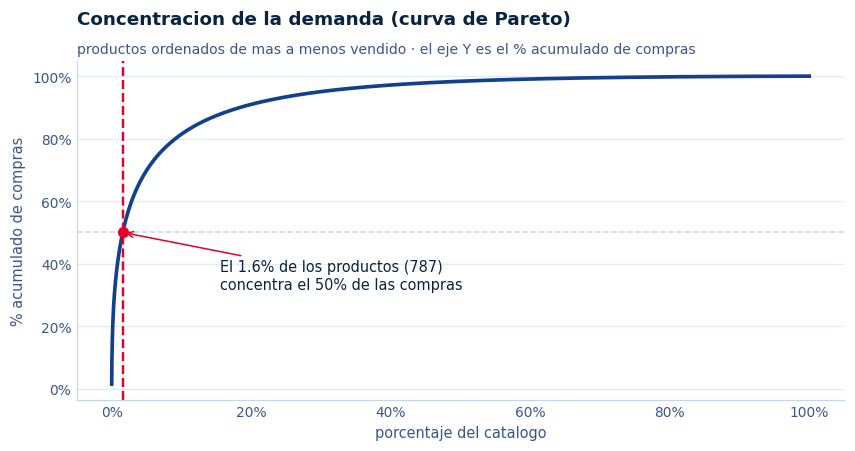

Head del catalogo: 787 productos (1.6%) = 50% de las compras. El resto es cola larga.


In [2]:
# Curva de concentracion: que % de las compras acumulan los productos ordenados por popularidad
pc = sql("""SELECT product_id, COUNT(*) c FROM prior GROUP BY product_id ORDER BY c DESC""")
pc["acum"] = pc["c"].cumsum()/pc["c"].sum()
pc["rank_pct"] = (np.arange(1,len(pc)+1))/len(pc)
idx50 = int((pc["acum"]>=0.5).idxmax()); prod50 = idx50+1; pct_cat50 = prod50/len(pc)

fig, ax = plt.subplots(figsize=(9,4))
ax.plot(pc["rank_pct"]*100, pc["acum"]*100, color=AZUL, lw=2.4)
ax.axhline(50, color=EJE, lw=1, ls="--"); ax.axvline(pct_cat50*100, color=ROJO, lw=1.6, ls="--")
ax.scatter([pct_cat50*100],[50], color=ROJO, zorder=5, s=40)
ax.annotate(f"El {pct_cat50*100:.1f}% de los productos ({prod50:,})\nconcentra el 50% de las compras",
            xy=(pct_cat50*100,50), xytext=(pct_cat50*100+14,32), color=TINTA,
            fontsize=9.5, arrowprops=dict(arrowstyle="->",color=ROJO))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x,_: f"{x:.0f}%"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x,_: f"{x:.0f}%"))
ejes(ax,"Concentracion de la demanda (curva de Pareto)",
     "productos ordenados de mas a menos vendido · el eje Y es el % acumulado de compras",
     "porcentaje del catalogo","% acumulado de compras")
guardar(fig,"assoc_01_concentracion"); plt.show()
print(f"Head del catalogo: {prod50:,} productos ({pct_cat50:.1%}) = 50% de las compras. El resto es cola larga.")

**Lectura.** La demanda esta tan concentrada que ordenar por popularidad no distingue relaciones:
los productos de la cabeza aparecen con todo simplemente porque aparecen en todo. Para descubrir
verdaderas parejas de compra necesitamos una metrica que **descuente** esa popularidad. Ese es el
trabajo del lift, que definimos ahora.


## 2. Support, confidence y lift: que mide cada una

Una regla de asociacion se escribe **A -> B** ("quien lleva A tiende a llevar B"). Se evalua con tres
numeros. Sea N el total de pedidos:

- **Support(A, B) = pedidos con A y B / N.** Que tan **frecuente** es el par en el total. Sirve para
  descartar coincidencias raras (pares con poquisimos casos no son accionables).
- **Confidence(A -> B) = pedidos con A y B / pedidos con A.** De los que llevan A, que fraccion
  **ademas** lleva B. Es una probabilidad condicional, pero tiene una trampa: si B es popular, la
  confidence sale alta aunque no haya relacion real.
- **Lift(A, B) = Support(A, B) / (Support(A) · Support(B)) = confidence(A -> B) / Support(B).**
  Compara la probabilidad de que aparezcan **juntos** contra la que se esperaria si fueran
  **independientes**. Interpretacion directa:
  - **lift = 1**: A y B son independientes (aparecen juntos lo justo por azar).
  - **lift > 1**: aparecen juntos **mas** de lo esperado. Hay asociacion (posible complemento).
  - **lift < 1**: aparecen juntos **menos** de lo esperado. Se **evitan** (posibles sustitutos).

**Por que lift y no confidence ni conteo.** El lift divide por la popularidad de B, asi que corrige
el sesgo que arruina al conteo y a la confidence. Un lift de 4 significa "este par aparece junto 4
veces mas de lo que su popularidad individual explicaria": eso es senal, no ruido.


In [3]:
# Ejemplo numerico concreto para fijar las formulas (dos productos frecuentes que suelen ir juntos)
def stats_par(nameA, nameB):
    idA = con.execute("SELECT product_id FROM catalogo WHERE product_name=? ", [nameA]).fetchone()
    idB = con.execute("SELECT product_id FROM catalogo WHERE product_name=? ", [nameB]).fetchone()
    if not idA or not idB: return None
    a,b = idA[0], idB[0]
    cA = con.execute("SELECT COUNT(DISTINCT order_id) FROM prior WHERE product_id=?", [a]).fetchone()[0]
    cB = con.execute("SELECT COUNT(DISTINCT order_id) FROM prior WHERE product_id=?", [b]).fetchone()[0]
    co = con.execute("""SELECT COUNT(*) FROM (SELECT order_id FROM prior WHERE product_id=? INTERSECT
                        SELECT order_id FROM prior WHERE product_id=?)""",[a,b]).fetchone()[0]
    supAB, supA, supB = co/N, cA/N, cB/N
    return dict(A=nameA,B=nameB,pedidos_A=cA,pedidos_B=cB,juntos=co,
                support=round(supAB,5),confidence_A_a_B=round(co/cA,3),
                lift=round(supAB/(supA*supB),2))

ej = stats_par("Organic Strawberries","Organic Hass Avocado") or stats_par("Banana","Organic Avocado")
print(pd.Series(ej).to_string())
print("\\nLectura: confidence dice 'de los que llevan A, que fraccion lleva B'.")
print("El lift compara ese juntarse contra el azar: >1 = van juntos mas de lo esperado.")

A                   Organic Strawberries
B                   Organic Hass Avocado
pedidos_A                         264683
pedidos_B                         213584
juntos                             40794
support                          0.01269
confidence_A_a_B                   0.154
lift                                2.32
\nLectura: confidence dice 'de los que llevan A, que fraccion lleva B'.
El lift compara ese juntarse contra el azar: >1 = van juntos mas de lo esperado.


## 3. Por que el conteo crudo engania (y el lift lo arregla)

Primero mostramos el problema. Si ordenamos las parejas por **cantidad de veces que aparecen juntas**,
el ranking se llena de la cabeza popular: banana con casi todo. No porque "banana llame a la palta",
sino porque banana esta en todos lados. Es un ranking inutil para recomendar.


Pares candidatos (top-400, co>=500): 19720


figura -> /sessions/tender-determined-rubin/mnt/outputs/reports/figures/assoc_02_conteo_crudo.png


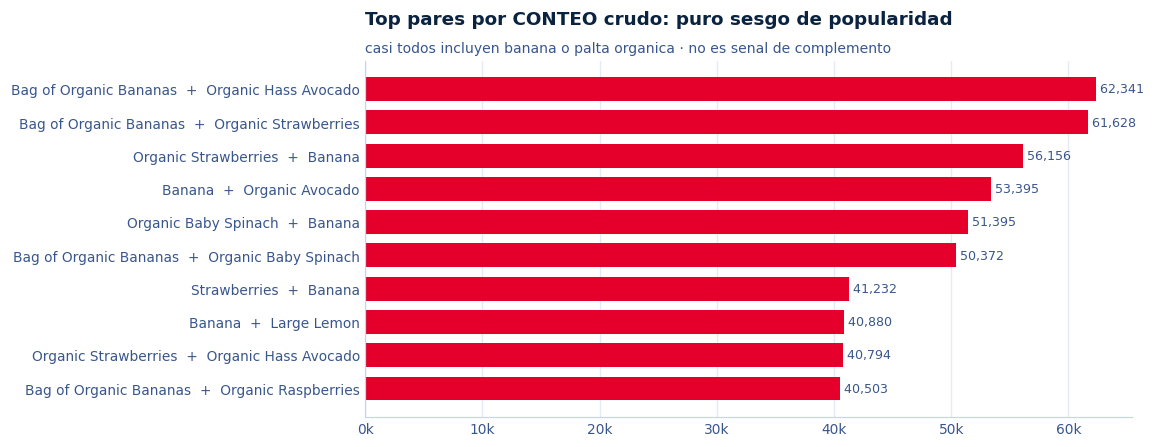

Observa: la banana domina. El conteo mide popularidad, no afinidad.


In [4]:
# --- Construir pares SOLO entre los productos mas populares (memory-safe) ---
TOPN = 400          # nos quedamos con el top-400 para que el self-join entre en memoria
MIN_CO = 500        # descartamos pares con menos de 500 co-ocurrencias (ruido)
con.execute("CREATE OR REPLACE TABLE cnt AS SELECT product_id, COUNT(*) c FROM prior GROUP BY product_id")
con.execute(f"CREATE OR REPLACE TABLE topp AS SELECT product_id FROM cnt ORDER BY c DESC LIMIT {TOPN}")
con.execute("CREATE OR REPLACE TABLE b AS SELECT order_id, product_id FROM prior WHERE product_id IN (SELECT product_id FROM topp)")
con.execute(f"""CREATE OR REPLACE TABLE pares AS
  SELECT x.product_id a, y.product_id b, COUNT(*) co
  FROM b x JOIN b y ON x.order_id=y.order_id AND x.product_id<y.product_id
  GROUP BY 1,2 HAVING COUNT(*)>={MIN_CO}""")
print("Pares candidatos (top-%d, co>=%d): %d" % (TOPN, MIN_CO, con.execute("SELECT COUNT(*) FROM pares").fetchone()[0]))

crudo = sql(f"""SELECT na.product_name A, nb.product_name B, p.co
  FROM pares p JOIN catalogo na ON p.a=na.product_id JOIN catalogo nb ON p.b=nb.product_id
  ORDER BY p.co DESC LIMIT 10""")

fig, ax = plt.subplots(figsize=(9,4.2))
lab = [f"{corto(r.A,22)}  +  {corto(r.B,22)}" for r in crudo.itertuples()]
ax.barh(range(len(crudo)), crudo["co"], color=ROJO, height=.72)
ax.set_yticks(range(len(crudo))); ax.set_yticklabels(lab, fontsize=8.4); ax.invert_yaxis()
for i,v in enumerate(crudo["co"]): ax.text(v, i, f" {v:,}", va="center", color=TINTA2, fontsize=8.3)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x,_: f"{x/1000:.0f}k"))
ejes(ax,"Top pares por CONTEO crudo: puro sesgo de popularidad",
     "casi todos incluyen banana o palta organica · no es senal de complemento", grid="x")
guardar(fig,"assoc_02_conteo_crudo"); plt.show()
print("Observa: la banana domina. El conteo mide popularidad, no afinidad.")

**Lectura.** El ranking por conteo es una lista de los productos mas populares emparejados entre
si. No sirve para recomendar porque el cliente ya iba a comprar esos productos. Ahora reordenamos
exactamente los mismos pares por **lift** y aparecen relaciones reales.

> **Alcance metodologico (importante).** Para que el self-join entre en memoria, las reglas a nivel
> producto se calculan sobre los **400 productos mas comprados** y pares con **al menos 500
> co-ocurrencias**. Es una estrategia memory-safe deliberada, pero implica que estos resultados
> **describen la cabeza del catalogo, no la cola larga ni todo el surtido**. Un motor en produccion
> tendria que recorrer el catalogo completo por lotes. Las reglas a nivel pasillo y departamento
> (seccion 5) si cubren todo el catalogo, porque agregan por categoria.


## 4. Reglas por lift a nivel producto: candidatos a complementos

Tomamos los mismos pares y los ordenamos por lift. El resultado ya no es "lo mas vendido". Ahora bien,
**un lift alto prueba asociacion estadistica, no complementariedad por si sola**: dos productos pueden
aparecer juntos por ser variantes de una misma linea o por otras razones. Por eso los tratamos como
**candidatos a complementos**, a validar despues, no como complementos confirmados.


,A,B,co,conf_A_a_B,conf_B_a_A,lift
0,Icelandic Style Skyr Blueberry Non-fat Yogurt,Non Fat Raspberry Yogurt,7224,0.375,0.441,73.6
1,Vanilla Skyr Nonfat Yogurt,Icelandic Style Skyr Blueberry Non-fat Yogurt,6653,0.367,0.345,61.2
2,Vanilla Skyr Nonfat Yogurt,Non Fat Raspberry Yogurt,5097,0.281,0.311,55.2
3,Total 2% Lowfat Greek Strained Yogurt With Blu...,Total 2% Lowfat Greek Strained Yogurt with Peach,6282,0.303,0.316,48.9
4,Total 2% Lowfat Greek Strained Yogurt With Blu...,Total 2% with Strawberry Lowfat Greek Strained...,9331,0.450,0.312,48.3
5,Packaged Grape Tomatoes,Baby Cucumbers,2848,0.213,0.198,47.6
6,Total 2% Lowfat Greek Strained Yogurt With Blu...,Total 2% Greek Strained Yogurt with Cherry 5.3 oz,5292,0.255,0.293,45.4
7,Total 2% Lowfat Greek Strained Yogurt with Peach,Total 2% Greek Strained Yogurt with Cherry 5.3 oz,4955,0.249,0.275,44.3
8,Total 2% with Strawberry Lowfat Greek Strained...,Total 2% Lowfat Greek Strained Yogurt with Peach,8014,0.268,0.403,43.3
9,Organic Bunny Fruit Snacks Berry Patch,Organic Summer Strawberry Bunny Fruit Snacks,2258,0.169,0.180,43.2


figura -> /sessions/tender-determined-rubin/mnt/outputs/reports/figures/assoc_03_lift_producto.png


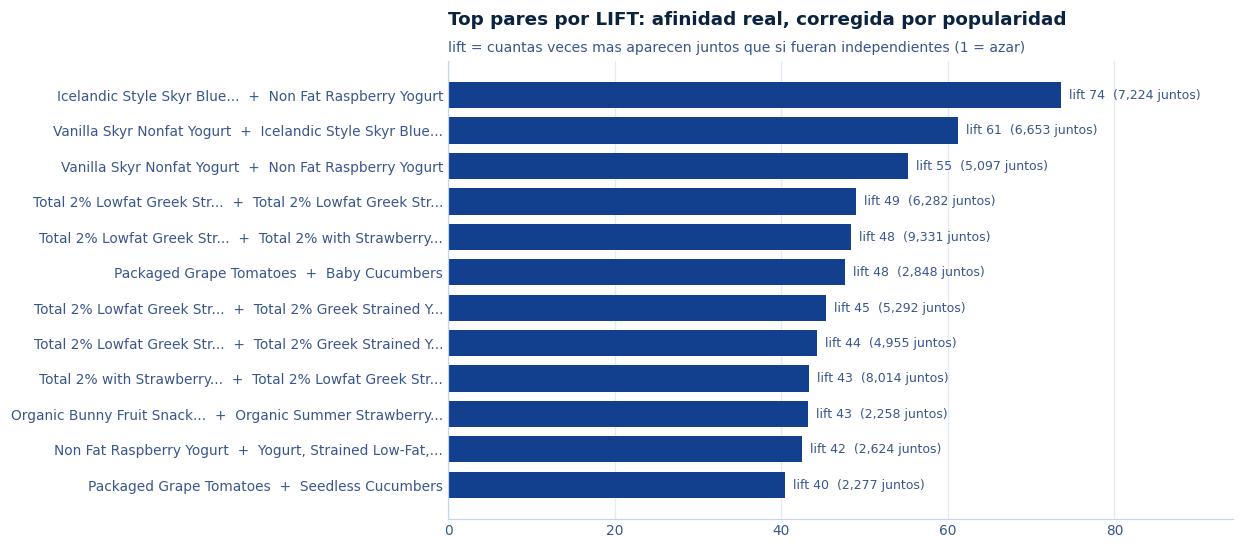

In [5]:
reglas = sql(f"""
  SELECT na.product_name A, nb.product_name B, p.co,
         ROUND(p.co*1.0/ca.c,3) conf_A_a_B,
         ROUND(p.co*1.0/cb.c,3) conf_B_a_A,
         ROUND((p.co*{N}.0)/(ca.c*cb.c),1) lift
  FROM pares p
  JOIN cnt ca ON p.a=ca.product_id JOIN cnt cb ON p.b=cb.product_id
  JOIN catalogo na ON p.a=na.product_id JOIN catalogo nb ON p.b=nb.product_id
  ORDER BY lift DESC LIMIT 15""")
display(reglas)

top = reglas.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(9.2,5.4))
lab = [f"{corto(r.A,26)}  +  {corto(r.B,26)}" for r in top.itertuples()]
ax.barh(range(len(top)), top["lift"], color=AZUL, height=.74)
for i,(v,co) in enumerate(zip(top["lift"], top["co"])):
    ax.text(v, i, f"  lift {v:.0f}  ({co:,} juntos)", va="center", color=TINTA2, fontsize=8.2)
ax.set_yticks(range(len(top))); ax.set_yticklabels(lab, fontsize=8.4)
ax.set_xlim(0, top["lift"].max()*1.28)
ejes(ax,"Top pares por LIFT: afinidad real, corregida por popularidad",
     "lift = cuantas veces mas aparecen juntos que si fueran independientes (1 = azar)", grid="x")
guardar(fig,"assoc_03_lift_producto"); plt.show()

**Como se leen estas reglas (tres tipos de relacion, a separar).** El lift alto no distingue
solo, hay que mirar el par:

- **Variantes de la misma linea** (lift altisimo, ej. yogures del mismo sabor entre si): NO son
  complementos, es el cliente armando su tanda. Hay que filtrarlas o marcarlas aparte.
- **Complementos** (se usan juntos, ej. helado con toppings, pasta con salsa a nivel pasillo): la
  recomendacion clasica de canasta, y es lo que pidio el P.O.
- **Sustitutos**: uno reemplaza al otro. Suelen aparecer con lift **menor a 1** (se evitan), pero
  tambien puede haber pares de lift alto que en negocio no convenga sugerir juntos.

El punto para el equipo: el mismo dato que por conteo era inutil, por lift entrega **candidatos** de
complemento accionables, que despues se separan de variantes y sustitutos con un filtro o validacion
de negocio.


figura -> /sessions/tender-determined-rubin/mnt/outputs/reports/figures/assoc_04_dist_lift.png


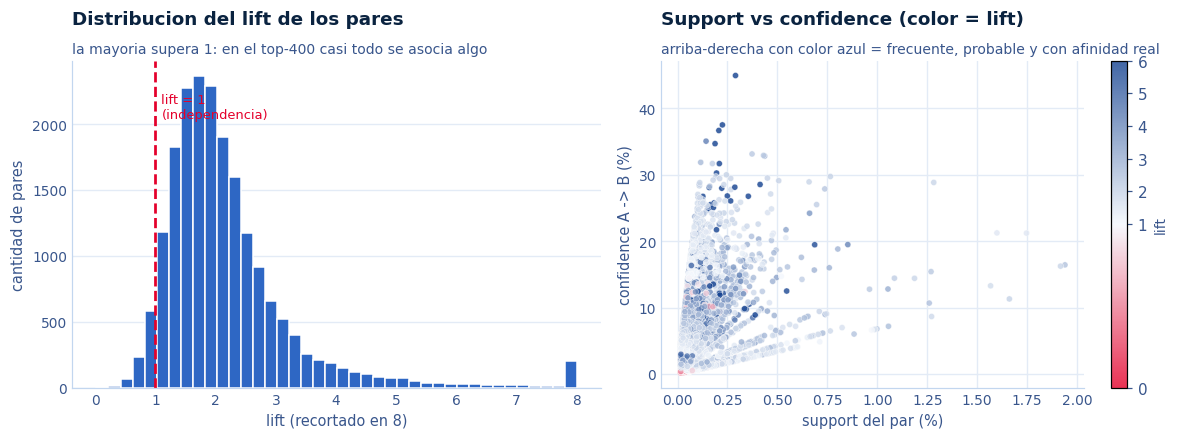

In [6]:
# Distribucion del lift (donde esta la senal) + relacion support vs confidence
todos = sql(f"""SELECT p.co, p.co*1.0/{N} support, p.co*1.0/ca.c confianza,
                   (p.co*{N}.0)/(ca.c*cb.c) lift
             FROM pares p JOIN cnt ca ON p.a=ca.product_id JOIN cnt cb ON p.b=cb.product_id""")
fig, axs = plt.subplots(1,2,figsize=(11.5,4.1))
ax=axs[0]
ax.hist(np.clip(todos["lift"],0,8), bins=40, color=AZUL_MED, edgecolor="white")
ax.axvline(1, color=ROJO, lw=1.8, ls="--"); ax.text(1.1,ax.get_ylim()[1]*0.9,"lift = 1\n(independencia)",color=ROJO,fontsize=8.5,va="top")
ejes(ax,"Distribucion del lift de los pares","la mayoria supera 1: en el top-400 casi todo se asocia algo", "lift (recortado en 8)","cantidad de pares")
ax=axs[1]
sc=ax.scatter(todos["support"]*100, todos["confianza"]*100, c=np.clip(todos["lift"],0,6),
              cmap=CMAP, s=16, alpha=.8, edgecolor="white", linewidth=.3, norm=TwoSlopeNorm(vmin=0,vcenter=1,vmax=6))
cb=fig.colorbar(sc,ax=ax); cb.set_label("lift",color=TINTA2,fontsize=9); cb.ax.tick_params(colors=TINTA2)
ejes(ax,"Support vs confidence (color = lift)","arriba-derecha con color azul = frecuente, probable y con afinidad real","support del par (%)","confidence A -> B (%)",grid="both")
plt.tight_layout(); guardar(fig,"assoc_04_dist_lift"); plt.show()

## 5. Subir de producto a pasillo y departamento

A nivel producto hay mucho detalle pero tambien mucho ruido de marca. Para una regla de negocio
interpretable ("si el carrito tiene X, ofrecer Y") conviene mirar por **pasillo** (134 categorias) y
**departamento** (21). Aca las relaciones son mas estables y faciles de explicar.


,A,B,co,conf_A_a_B,lift
0,red wines,white wines,7738,0.306,38.90
1,beers coolers,red wines,5317,0.179,22.70
2,beers coolers,white wines,4569,0.154,19.54
3,baking supplies decor,doughs gelatins bake mixes,4286,0.207,7.44
4,oral hygiene,body lotions soap,4367,0.078,7.10
5,laundry,cleaning products,13928,0.174,6.32
6,tofu meat alternatives,frozen vegan vegetarian,16122,0.152,6.24
7,trash bags liners,cleaning products,4978,0.162,5.90
8,cleaning products,body lotions soap,5624,0.064,5.75
9,dish detergents,laundry,12096,0.137,5.52


figura -> /sessions/tender-determined-rubin/mnt/outputs/reports/figures/assoc_05_lift_pasillo.png


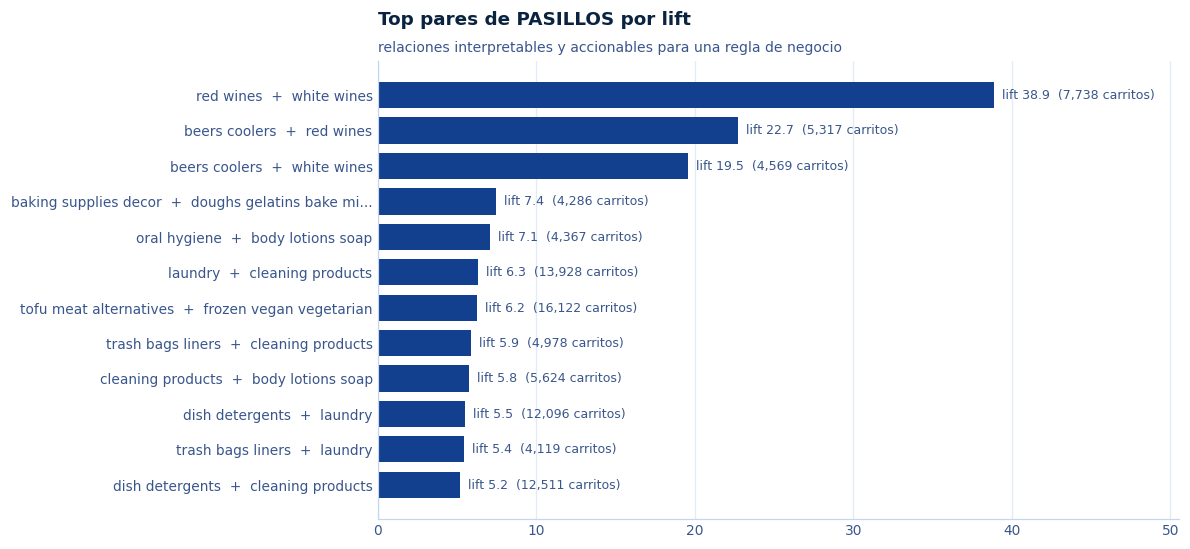

In [7]:
# Co-ocurrencia a nivel PASILLO (un pasillo por orden, distinto), ordenado por lift
con.execute("""CREATE OR REPLACE TABLE oa AS
  SELECT DISTINCT op.order_id, c.aisle_id, c.aisle FROM prior op JOIN catalogo c USING(product_id)""")
con.execute("CREATE OR REPLACE TABLE acnt AS SELECT aisle_id, COUNT(*) c FROM oa GROUP BY aisle_id")
pas = sql(f"""
  WITH ap AS (SELECT x.aisle xa, y.aisle ya, x.aisle_id ia, y.aisle_id ja, COUNT(*) co
              FROM oa x JOIN oa y ON x.order_id=y.order_id AND x.aisle_id<y.aisle_id
              GROUP BY 1,2,3,4 HAVING COUNT(*)>=4000)
  SELECT xa A, ya B, co, ROUND(co*1.0/ca.c,3) conf_A_a_B,
         ROUND((co*{N}.0)/(ca.c*cb.c),2) lift
  FROM ap JOIN acnt ca ON ap.ia=ca.aisle_id JOIN acnt cb ON ap.ja=cb.aisle_id
  ORDER BY lift DESC LIMIT 15""")
display(pas)

top = pas.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(9.4,5.4))
lab=[f"{corto(r.A,24)}  +  {corto(r.B,24)}" for r in top.itertuples()]
ax.barh(range(len(top)), top["lift"], color=AZUL, height=.74)
for i,(v,co) in enumerate(zip(top["lift"],top["co"])):
    ax.text(v,i,f"  lift {v:.1f}  ({co:,} carritos)",va="center",color=TINTA2,fontsize=8.2)
ax.set_yticks(range(len(top))); ax.set_yticklabels(lab, fontsize=8.5)
ax.set_xlim(0, top["lift"].max()*1.3)
ejes(ax,"Top pares de PASILLOS por lift","relaciones interpretables y accionables para una regla de negocio", grid="x")
guardar(fig,"assoc_05_lift_pasillo"); plt.show()

**Lectura.** Estas si son reglas para un product owner: vinos tintos con blancos, salsa para
pasta con pasta seca, lavanderia con productos de limpieza, sustitutos de carne con congelados
veganos. Tienen co-ocurrencia alta (miles de carritos) y lift alto a la vez, o sea que no son ni
raras ni casuales. Al agregar por categoria hay menos ruido de variantes que a nivel producto, asi que
son buenos **candidatos de complemento** para un motor de sugerencias.


figura -> /sessions/tender-determined-rubin/mnt/outputs/reports/figures/assoc_06_heatmap_depto.png


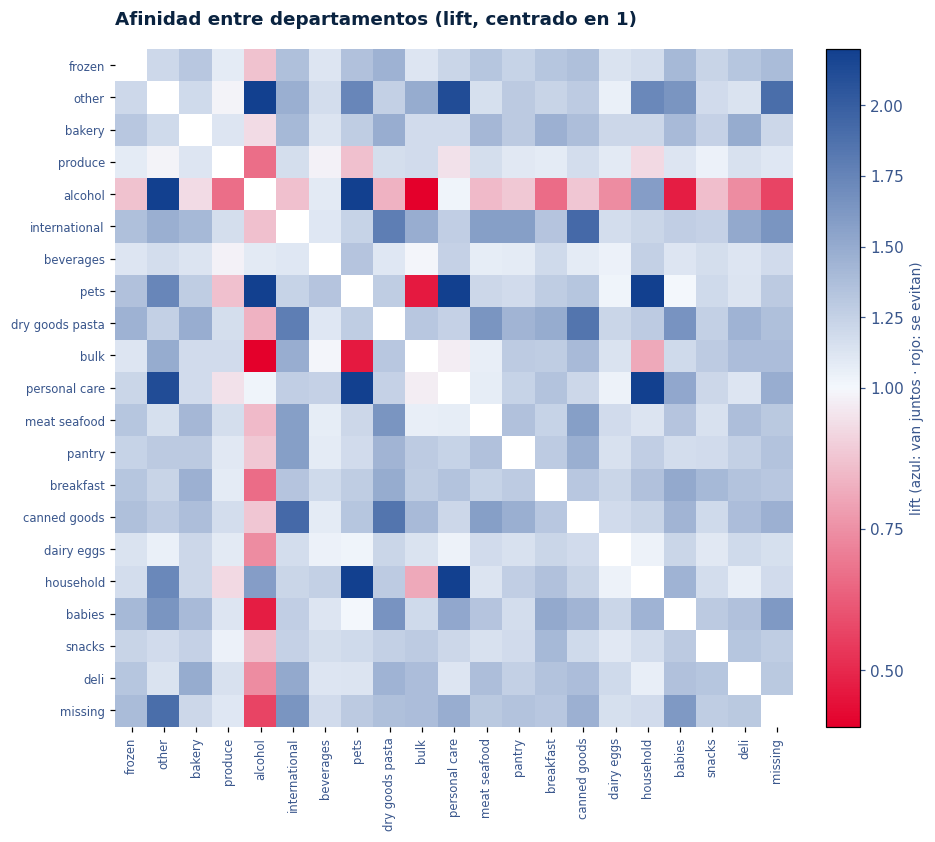

Azul = se compran juntos mas de lo esperado; rojo = se evitan (posibles sustitutos o canastas distintas).


In [8]:
# Heatmap de lift entre DEPARTAMENTOS (21x21): mapa global de afinidades y rechazos
con.execute("""CREATE OR REPLACE TABLE od AS
  SELECT DISTINCT op.order_id, c.department_id, c.department FROM prior op JOIN catalogo c USING(product_id)""")
con.execute("CREATE OR REPLACE TABLE dcnt AS SELECT department_id, department, COUNT(*) c FROM od GROUP BY 1,2")
dl = sql(f"""
  WITH dp AS (SELECT x.department_id i, y.department_id j, COUNT(*) co
              FROM od x JOIN od y ON x.order_id=y.order_id AND x.department_id<y.department_id GROUP BY 1,2)
  SELECT i, j, (co*{N}.0)/(ci.c*cj.c) lift FROM dp
  JOIN dcnt ci ON dp.i=ci.department_id JOIN dcnt cj ON dp.j=cj.department_id""")
deps = sql("SELECT department_id, department FROM dcnt ORDER BY department_id")
name = dict(zip(deps.department_id, deps.department)); ids=list(deps.department_id)
M = np.full((len(ids),len(ids)), np.nan); pos={d:k for k,d in enumerate(ids)}
for r in dl.itertuples():
    M[pos[r.i],pos[r.j]]=r.lift; M[pos[r.j],pos[r.i]]=r.lift

fig, ax = plt.subplots(figsize=(9.6,8))
im=ax.imshow(M, cmap=CMAP, norm=TwoSlopeNorm(vmin=0.4,vcenter=1.0,vmax=2.2))
ax.set_xticks(range(len(ids))); ax.set_yticks(range(len(ids)))
ax.set_xticklabels([name[d] for d in ids], rotation=90, fontsize=7.6, color=TINTA2)
ax.set_yticklabels([name[d] for d in ids], fontsize=7.6, color=TINTA2)
cb=fig.colorbar(im,ax=ax,fraction=0.046,pad=0.04); cb.set_label("lift (azul: van juntos · rojo: se evitan)",color=TINTA2,fontsize=9); cb.ax.tick_params(colors=TINTA2)
ax.set_title("Afinidad entre departamentos (lift, centrado en 1)",color=TINTA,fontsize=12,fontweight="bold",loc="left",pad=16)
for sp in ax.spines.values(): sp.set_visible(False)
guardar(fig,"assoc_06_heatmap_depto"); plt.show()
print("Azul = se compran juntos mas de lo esperado; rojo = se evitan (posibles sustitutos o canastas distintas).")

## 6. Cuidado: los pasillos son gruesos para "producto similar"

Las reglas de pasillo sirven para complementos ("otro pasillo que combina"). Pero si la idea es
"sugerir un producto **similar** al que le gusta", el pasillo se queda corto: cada pasillo agrupa
cientos de productos muy distintos entre si.


figura -> /sessions/tender-determined-rubin/mnt/outputs/reports/figures/assoc_07_granularidad.png


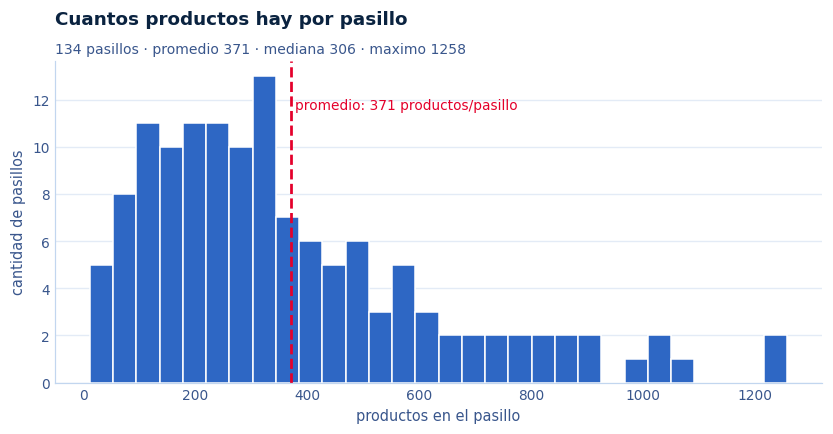

En promedio 371 productos por pasillo (max 1258). Para 'similar pero no igual', el pasillo es demasiado amplio:
mejor las reglas por producto (lift) o, si no alcanzan, una categoria mas fina construida a proposito.


In [9]:
pp = sql("SELECT aisle_id, COUNT(*) n FROM catalogo GROUP BY aisle_id")
prom, med, mx = pp.n.mean(), pp.n.median(), pp.n.max()
fig, ax = plt.subplots(figsize=(9,3.8))
ax.hist(pp["n"], bins=30, color=AZUL_MED, edgecolor="white")
ax.axvline(prom, color=ROJO, lw=1.8, ls="--")
ax.text(prom+8, ax.get_ylim()[1]*0.85, f"promedio: {prom:.0f} productos/pasillo", color=ROJO, fontsize=9)
ejes(ax,"Cuantos productos hay por pasillo","134 pasillos · promedio %.0f · mediana %.0f · maximo %d" % (prom,med,mx),
     "productos en el pasillo","cantidad de pasillos")
guardar(fig,"assoc_07_granularidad"); plt.show()
print(f"En promedio {prom:.0f} productos por pasillo (max {mx}). Para 'similar pero no igual', el pasillo es demasiado amplio:")
print("mejor las reglas por producto (lift) o, si no alcanzan, una categoria mas fina construida a proposito.")

## 7. Categoria y recompra: hay solapamiento con `reorder_rate_producto`

Queda la pregunta de si valdria la pena meter el departamento o el pasillo como variable del modelo de
**recompra**. Lo que muestra este analisis es que **la parte util de la categoria (que tan repetible
es) solapa con una variable que el modelo ya usa**, `reorder_rate_producto`. Ojo con el alcance: esto
sugiere solapamiento, **no prueba** que la categoria no aporte senal incremental. Para afirmar eso
haria falta una prueba controlada del modelo con y sin esas variables. Lo mostramos con la tasa de
recompra por departamento.


figura -> /sessions/tender-determined-rubin/mnt/outputs/reports/figures/assoc_08_reorder_depto.png


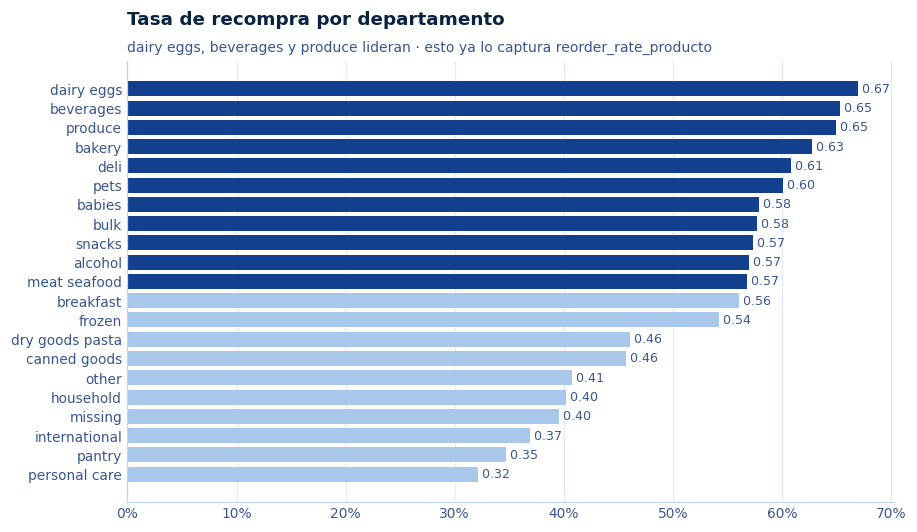

La categoria se relaciona con la recompra sobre todo por 'que tan repetible es el producto', que ya entra al modelo.
Hay solapamiento con reorder_rate_producto; para afirmar redundancia habria que medir el modelo con y sin la categoria.


In [10]:
rr = sql("""SELECT c.department, ROUND(AVG(op.reordered),3) reorder_rate, COUNT(*) n
  FROM prior op JOIN catalogo c USING(product_id) GROUP BY 1 ORDER BY reorder_rate DESC""")
fig, ax = plt.subplots(figsize=(9,5.2))
cols=[AZUL if v>=rr.reorder_rate.median() else AZUL_CLARO for v in rr.reorder_rate]
ax.barh(range(len(rr)), rr["reorder_rate"], color=cols, height=.78)
ax.set_yticks(range(len(rr))); ax.set_yticklabels(rr["department"], fontsize=8.6); ax.invert_yaxis()
for i,v in enumerate(rr["reorder_rate"]): ax.text(v,i,f" {v:.2f}",va="center",color=TINTA2,fontsize=8.3)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x,_:f"{x:.0%}"))
ejes(ax,"Tasa de recompra por departamento","dairy eggs, beverages y produce lideran · esto ya lo captura reorder_rate_producto", grid="x")
guardar(fig,"assoc_08_reorder_depto"); plt.show()
print("La categoria se relaciona con la recompra sobre todo por 'que tan repetible es el producto', que ya entra al modelo.")
print("Hay solapamiento con reorder_rate_producto; para afirmar redundancia habria que medir el modelo con y sin la categoria.")

## 8. Variables que dejamos fuera y podrian sumar

Aprovechando el analisis, revisamos senal en variables que hoy **no** entran (o entran poco) al
modelo, para ver si hay una mejora facil ademas de las reglas de asociacion.

> **Cuidado con la fuga.** Estas variables solo son utilizables si provienen del **historial** o de
> informacion disponible **al momento de recomendar**. El **tamano final** del pedido objetivo y las
> **posiciones** de ese pedido NO estan disponibles cuando recomendamos: usarlas seria fuga. Aca las
> miramos de forma descriptiva sobre el historico; para el modelo solo servirian sus versiones
> derivadas del pasado (por ejemplo, tamano promedio historico del cliente).


figura -> /sessions/tender-determined-rubin/mnt/outputs/reports/figures/assoc_09_dow_depto.png


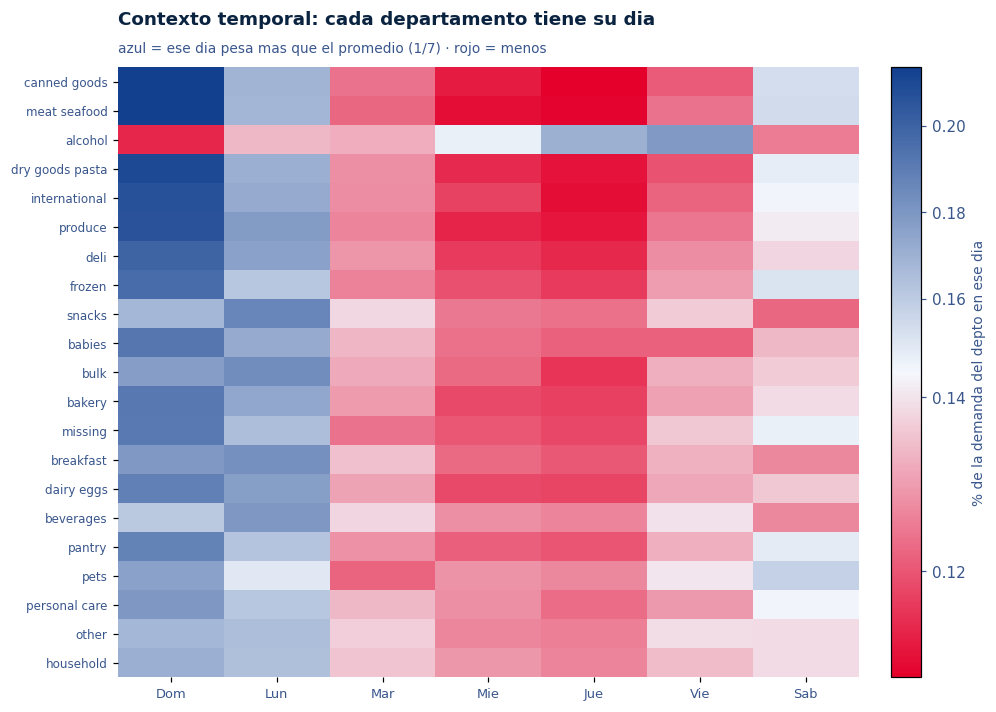

Hay estacionalidad de dia por categoria (alcohol, produce). El modelo de recompra usa contexto de la orden objetivo,
pero un motor de complementos podria condicionarse al dia. Es una feature de contexto candidata.


In [11]:
# (a) Contexto temporal: sesgo de cada departamento por dia de la semana (0=dom ... 6=sab)
tmp = sql("""SELECT c.department, o.order_dow dow, COUNT(*) n
  FROM prior op JOIN orders o USING(order_id) JOIN catalogo c USING(product_id)
  GROUP BY 1,2""")
piv = tmp.pivot(index="department", columns="dow", values="n").fillna(0)
share = piv.div(piv.sum(axis=1), axis=0)           # % de cada depto por dia
idx = share.mul((share.values/share.mean(axis=0).values)).max(axis=1).sort_values(ascending=False).index
share = share.loc[idx]
fig, ax = plt.subplots(figsize=(9.5,7.2))
im=ax.imshow(share.values, cmap=CMAP, aspect="auto",
             norm=TwoSlopeNorm(vmin=share.values.min(), vcenter=1/7, vmax=share.values.max()))
ax.set_xticks(range(7)); ax.set_xticklabels(["Dom","Lun","Mar","Mie","Jue","Vie","Sab"], fontsize=8.5, color=TINTA2)
ax.set_yticks(range(len(share))); ax.set_yticklabels(share.index, fontsize=7.8, color=TINTA2)
cb=fig.colorbar(im,ax=ax,fraction=0.046,pad=0.04); cb.set_label("% de la demanda del depto en ese dia",color=TINTA2,fontsize=9); cb.ax.tick_params(colors=TINTA2)
ax.set_title("Contexto temporal: cada departamento tiene su dia",color=TINTA,fontsize=12,fontweight="bold",loc="left",pad=28)
ax.text(0,1.02,"azul = ese dia pesa mas que el promedio (1/7) · rojo = menos",transform=ax.transAxes,color=TINTA2,fontsize=9,va="bottom")
for sp in ax.spines.values(): sp.set_visible(False)
guardar(fig,"assoc_09_dow_depto"); plt.show()
print("Hay estacionalidad de dia por categoria (alcohol, produce). El modelo de recompra usa contexto de la orden objetivo,")
print("pero un motor de complementos podria condicionarse al dia. Es una feature de contexto candidata.")

figura -> /sessions/tender-determined-rubin/mnt/outputs/reports/figures/assoc_10_contexto.png


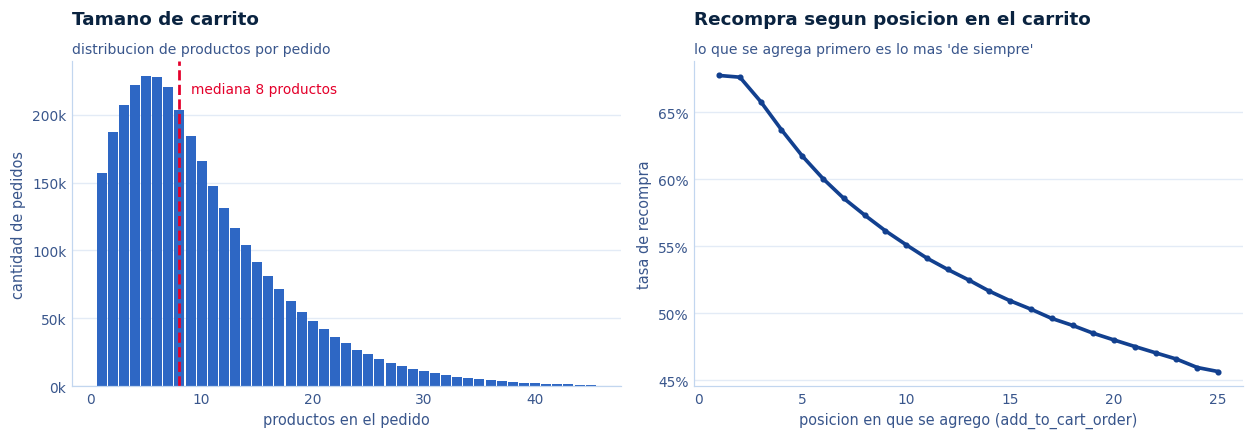

Mediana de carrito: 8 productos. Lo primero que entra al carrito se recompra mucho mas que lo ultimo:
la posicion tiene senal de 'producto core', aunque debil para el ranking. Util para ordenar sugerencias, no como feature fuerte.


In [12]:
# (b) Tamano de carrito y (c) posicion en el carrito vs recompra
sizes = sql("SELECT n_items, COUNT(*) ordenes FROM (SELECT order_id, COUNT(*) n_items FROM prior GROUP BY order_id) GROUP BY 1 ORDER BY 1")
pos = sql("SELECT add_to_cart_order pos, AVG(reordered) reorder_rate FROM prior WHERE add_to_cart_order<=25 GROUP BY 1 ORDER BY 1")
med_size = sql("SELECT MEDIAN(n_items) m FROM (SELECT order_id, COUNT(*) n_items FROM prior GROUP BY order_id)")["m"][0]

fig, axs = plt.subplots(1,2,figsize=(11.5,4.1))
ax=axs[0]
s = sizes[sizes.n_items<=45]
ax.bar(s["n_items"], s["ordenes"], color=AZUL_MED, width=.9)
ax.axvline(med_size, color=ROJO, lw=1.8, ls="--"); ax.text(med_size+1, ax.get_ylim()[1]*0.9, f"mediana {med_size:.0f} productos", color=ROJO, fontsize=9)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x,_:f"{x/1000:.0f}k"))
ejes(ax,"Tamano de carrito","distribucion de productos por pedido","productos en el pedido","cantidad de pedidos")
ax=axs[1]
ax.plot(pos["pos"], pos["reorder_rate"], color=AZUL, lw=2.4, marker="o", ms=3)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x,_:f"{x:.0%}"))
ejes(ax,"Recompra segun posicion en el carrito","lo que se agrega primero es lo mas 'de siempre'","posicion en que se agrego (add_to_cart_order)","tasa de recompra")
plt.tight_layout(); guardar(fig,"assoc_10_contexto"); plt.show()
print(f"Mediana de carrito: {med_size:.0f} productos. Lo primero que entra al carrito se recompra mucho mas que lo ultimo:")
print("la posicion tiene senal de 'producto core', aunque debil para el ranking. Util para ordenar sugerencias, no como feature fuerte.")

## 9. Conclusiones y decisiones para el Sprint 2

**Sobre la categoria (lo que se pregunto directo).**

1. El pasillo y el departamento **ya existen** en los datos; no hay que "crear categorias" para
   empezar. El modelo actual **no los uso** (no estan en `build_features.py`).
2. Para la **recompra**, la parte util de la categoria **solapa** con `reorder_rate_producto`, que el
   modelo ya usa. Esto sugiere que la categoria cruda aportaria poco, pero **no lo prueba**:
   confirmarlo requiere medir el modelo con y sin esas variables.

**Sobre la sugerencia del P.O. (productos complementarios).**

3. Las **reglas de asociacion con lift** entregan **candidatos a complementos**, tanto a nivel
   producto como a nivel pasillo (vinos con vinos, pasta con salsa, limpieza con lavanderia). El conteo
   crudo no sirve por el sesgo de popularidad; el **lift lo corrige**. Es la via directa para lo que
   pidio Ariel, separando despues variantes y sustitutos con validacion de negocio. A nivel producto
   se midio sobre la cabeza del catalogo (top-400), no sobre todo el surtido.
4. Los pasillos son **gruesos** (promedio de cientos de productos), asi que para "similar pero no
   igual" conviene la regla por producto. Una **categoria nueva con IA** (agrupar productos por
   co-compra o por embeddings) tiene sentido solo como **experimento a comparar contra las reglas**,
   no para construir a ciegas: se justifica si las reglas por producto se quedan cortas en cobertura.

**Variables candidatas fuera del modelo (bonus).**

5. **Contexto temporal (dia / hora):** hay estacionalidad por categoria. Vale como feature de
   contexto para un motor de complementos, no tanto para la recompra.
6. **Posicion en el carrito:** senal de "producto core", pero la posicion del pedido objetivo no esta
   disponible al recomendar (seria fuga). Solo usable en su version historica, util para **ordenar**
   sugerencias mas que como feature predictiva fuerte.
7. **Tamano de carrito:** el tamano del pedido objetivo tampoco esta disponible al recomendar (fuga).
   Solo sirve su version historica (tamano promedio del cliente), util para segmentar (compra grande
   del mes vs reposicion).

**Mi recomendacion para la Daily:** llevar reglas de asociacion (lift) al primer plano, separando
reglas de **recompra** de reglas de **descubrimiento**, y medir si mejoran novedad y tamano de
carrito. Dejar la categorizacion con IA como experimento contra las reglas, con criterio de exito
definido de antemano. Decidir con evidencia, no por intuicion.
